# **11766 Advanced Perception for Mobile Robotics**
## Master's Degree in Intelligent Systems
### University of the Balearic Islands
---

##### Write in the following the names of the members of the group:
- John Smith 1
- John Smith 2

## **Instructions**

- **Do not delete any of the provided cells or functions**. Write your code where it is indicated. You may add new cells or functions as needed to complete your work.
- Along with this assignment, please submit a comprehensive **report** in PDF format explaining your implemented solutions. This report can include, for instance:
    - A technical explanation: Clearly describe the algorithms and techniques used, including relevant code snippets.
    - Results: Present your results in a clear and concise manner. Use visualizations such as graphs or tables to enhance understanding.
    - Analysis: Interpret your results and discuss their significance. Consider, for instance, the following questions:
        - Are the results as expected? Why or why not?
        - What factors might have influenced the results?
    - Conclusions: Summarize your findings and provide overall conclusions about your project.


# **EKF Localization**

In this assignment you need to implement an EKF algorithm for localizing a robot in a given landmark map. 
The data for this exercise is recorded on a differential drive robot equipped with a sensor able to detect the distance and the angle of landmarks (e.g., beacons). After executing the following cell, the figure below visualizes the landmark map and the actual trajectory (ground truth) taken by the robot.

In [2]:
%load_ext autoreload
%autoreload 2

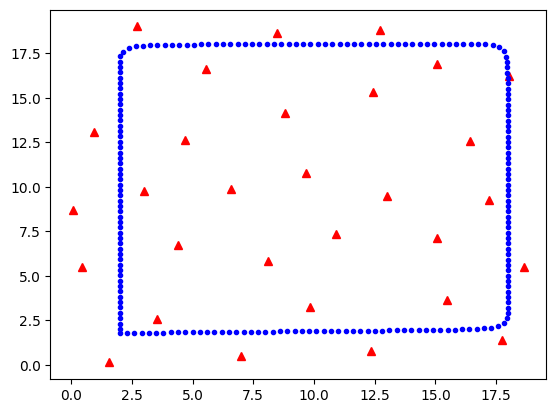

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from utils import *
%matplotlib inline

# Read dataset
data = pickle.load(open("data/dataset_2d_landmarks.p", "rb"))

# Get landmark coordinates 
M = data['M']

# Get ground truth trajectory
gt_traj = data['gt']

# Show map
plt.figure()
plt.plot(M[:,0], M[:,1], '^r')

# Show ground truth trajectory
for i in range(0,len(gt_traj), 10):
    plt.plot(gt_traj[i][0],gt_traj[i][1], '.b')

plt.show()

The following data is provided in `data`:

- *M* is the map of the environment where the robot must be localized, i.e.: the true coordinates of the landmarks in map frame.
- *gt* is the ground truth trajectory (true poses in the map frame). You may want to use them for checking your results.
- *odom* are the noisy odometry readings observed by the robot during navigation in the form: $\hat{x}_t,\hat{y}_t, \hat{\theta}_t$ in the odometry frame.
- *z* are the sensor measurements. Each measurement $z_t$, corresponding to the time step $t$, contains a set of observed landmarks $[\rho_i, \phi_i, id_i]$, where $\rho_i$ is the measured distance, $\phi_i$ is the measured angle, and $id_i$ is the id of the observed landmark. Note that this id corresponds to the index of the landmark in *M*.

You can access the `data` as follows:

In [5]:
# Get odomety at timestamp 10
odom_10 = data['odom'][10]
print("Odom at step 10 is: \n", odom_10)

# get observation at timestamp 10
z_10 = data['z'][10]
print("Observation at step 10 is: \n", z_10)

Odom at step 10 is: 
 [ 0.3449921   0.00058428 -0.02110238]
Observation at step 10 is: 
 [[ 2.1793557   1.27533718  3.5604415 ]
 [ 2.92652148 -1.4372858   0.4519207 ]
 [ 4.         11.         14.        ]]


## **Prediction**

The `ekf_predict` function computes a prediction about the robot's pose after moving by using the odometry motion model.

It takes as input:

- The current belief about the pose of the robot, represented as a Gaussian distribution $\mathcal{N}(\mu_{t-1},\Sigma_{t-1})$ 
- The odometry readings $u_t$, which is a list where $u_t[0]$ and $u_t[1]$ are the odometry readings at the previous time step ($t - 1$) and the current time step ($t$), respectively.
- The process noise $R_t$.

The output of this function is a prediction about the robot's pose in the next time step $t$, $\mathcal{N}(\overline{\mu}_{t},\overline{\Sigma}_{t})$. You are also provided with a function called `inv_motion_model` to compute $u_t = [\delta_{rot1}, \delta_{trans}, \delta_{rot2}]$ between two consecutive odometry readings.

**Tasks:**
- Implement the `ekf_predict` function in the `utils.py` file and verify if it is correct with the following cell. 

In [6]:
mu_t = np.array([2, 2, np.pi/2]).reshape(3, 1)
S_t = np.array([[1, 0, 0],[0, 1, 0], [0, 0, 1]])
R_t = np.zeros((3,3))
print('Before prediction')
print(mu_t)
print(S_t)
print('---')

u_p, S_p = ekf_predict(mu_t, S_t, np.array([[0,0,0],[1,0,0]]), R_t)

print('After prediction')
print(u_p)
print(S_p)

Before prediction
[[2.        ]
 [2.        ]
 [1.57079633]]
[[1 0 0]
 [0 1 0]
 [0 0 1]]
---
After prediction
[[2.        ]
 [3.        ]
 [1.57079633]]
[[ 2.000000e+00 -6.123234e-17 -1.000000e+00]
 [-6.123234e-17  1.000000e+00  6.123234e-17]
 [-1.000000e+00  6.123234e-17  1.000000e+00]]


## **Correction**

The `ekf_correct` implements the correction step of the EKF that corrects the prediction according to the sensor measurements.

It takes as input:

- The current prediction about the pose of the robot represented as a Gaussian distribution $\mathcal{N}(\overline{\mu}_{t},\overline{\Sigma}_{t})$
- The sensor measurements $z_t$. Remember that it each sensor measurement includes observations of several landmarks.
- The measurement noise $Q_t$.
- The map $M$.

The output is the new belief about the robot's pose $\mathcal{N}({\mu}_{t},{\Sigma}_{t})$.

**Tasks:**
- Implement the `ekf_correct` function in the `utils.py` file and verify that it is correct with the following cell. Use the provided function `wrapToPi` to ensure that each angle is between $-\pi$ and $\pi$ everywhere you deal with it.

In [41]:
# 3x3 Process noise
sigma_x = 0.25  # [m]
sigma_y = 0.25  # [m]
sigma_theta = np.deg2rad(10)  # [rad]
R = np.diag(np.array([sigma_x, sigma_y, sigma_theta])**2)

# 2x2 Observation noise
sigma_r = 0.1  # [m]
sigma_phi = np.deg2rad(5)  # [rad]
Q = np.diag(np.array([sigma_r, sigma_phi])**2)

# initial state
mu_bar = np.array([2, 2, np.pi/2]) 
S_bar = np.array([[1, 0, 0],[0, 1, 0], [0, 0, np.pi/3]])

for i in range(1,100):   
    u_t = [data['odom'][i-1], data['odom'][i]]
    mu_bar, S_bar = ekf_predict(mu_bar.reshape(3,1), S_bar, u_t, R)

print("Only running predict")
print(mu_bar)
print(S_bar)
print('---')

mu = np.array([2, 2, np.pi/2]) 
S = np.array([[1, 0, 0],[0, 1, 0], [0, 0, np.pi/3]])

for i in range(1,100):   
    u_t = [data['odom'][i-1],data['odom'][i]]
    z = data['z'][i]
    mu_bar, sigma_bar = ekf_predict(mu.reshape(3,1), S, u_t, R)
    mu, S = ekf_correct(mu_bar, sigma_bar, z, Q, M)
print("Running predict and correct")
print(mu)
print(S)
print('---')

print('Ground Truth Pose at 100')
print(gt_traj[100].reshape(3,1))

Only running predict
[[1.89063269]
 [5.01048817]
 [1.62486271]]
[[25.41378409  0.73391807 -7.55708829]
 [ 0.73391807  7.21762093 -0.32082104]
 [-7.55708829 -0.32082104  4.06291001]]
---
Running predict and correct
[[1.96692572]
 [4.93549478]
 [1.56139293]]
[[3.86546981e-03 2.11413377e-04 2.05449079e-04]
 [2.11413377e-04 2.15958953e-03 7.63262114e-05]
 [2.05449079e-04 7.63262114e-05 1.23325955e-03]]
---
Ground Truth Pose at 100
[[2.        ]
 [5.03      ]
 [1.57079633]]


## **Localization**

**Tasks:**

- Once you have completed all the above functions, implement the main procedure of an EKF localization algorithm, which recursively estimates the pose of the robot using the odometry data and the sensor measurements.

Assume that the initial belief at time $t=0$ is:

$\mu = [2, 2, \pi/2]'$\
$
\Sigma = \left(\begin{array}{cc} 
1 & 0 & 0\\
0 & 1 & 0 \\
0 & 0 & \pi/3
\end{array}\right)
$ 
            
The process noise $R$ and measurement noise $Q$ are defined, respectively, as:\
$R = \left(\begin{array}{cc} 
\sigma_x^2 & 0 & 0 \\
0 & \sigma_y^2 & 0 \\
0 & 0 &  \sigma_{theta}^2
\end{array}\right)
$

with $\sigma_x = 0.25$ meters, $\sigma_y = 0.25$ meters and $\sigma_{theta} = 10$ degrees, and 
 
$Q = 
\left(\begin{array}{cc} 
\sigma_r^2 & 0 \\
0 & \sigma_{phi}^2 
\end{array}\right)
$

with $\sigma_r = 0.10$ meters, $\sigma_{phi} = 5$ degrees. 

- Plot the estimated trajectory, along with the ground truth and the map, after processing the whole sequence.

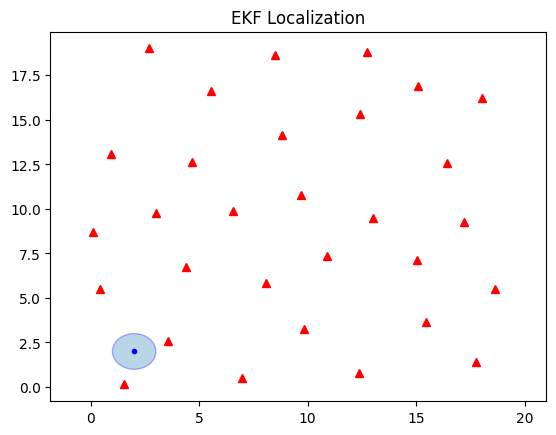

In [8]:
# 3x3 process noise
sigma_x = 0.25  # [m]
sigma_y = 0.25  # [m]
sigma_theta = np.deg2rad(10)  # [rad]
R = np.diag(np.array([sigma_x, sigma_y, sigma_theta])**2)

# 2x2 observation noise
sigma_r = 0.1  # [m]
sigma_phi = np.deg2rad(5)  # [rad]
Q = np.diag(np.array([sigma_r, sigma_phi])**2)

# initial state
mu = np.array([2, 2, np.pi/2]) 
S = np.array([[1, 0, 0],[0, 1, 0], [0, 0, np.pi/3]])

# visualize
plot_state(mu, S, M)

In [26]:
# Write here the code to process the full trajectory

# YOUR CODE HERE
def process_full_trajectory(data, mu0, S0, R, Q, M):
    """Run EKF over all timesteps and return trajectory, covariances and projected measurements."""
    estim_traj = []
    estim_cov = []
    meas_points = []

    mu = np.array(mu0, dtype=np.float64).reshape(3,)
    S = np.array(S0, dtype=np.float64).reshape(3, 3)

    estim_traj.append(mu.copy())
    estim_cov.append(S.copy())

    for i in range(1, len(data['odom'])):
        u_t = [data['odom'][i-1], data['odom'][i]]
        z_t = data['z'][i]

        # EKF predict + correct
        mu_bar, S_bar = ekf_predict(mu.reshape(3, 1), S, u_t, R)
        mu, S = ekf_correct(mu_bar, S_bar, z_t, Q, M)

        mu = np.array(mu, dtype=np.float64).reshape(3,)
        S = np.array(S, dtype=np.float64).reshape(3, 3)

        estim_traj.append(mu.copy())
        estim_cov.append(S.copy())

        # Project each range-bearing measurement to global frame
        for k in range(z_t.shape[1]):
            rho = z_t[0, k]
            phi = z_t[1, k]
            mx = mu[0] + rho * np.cos(mu[2] + phi)
            my = mu[1] + rho * np.sin(mu[2] + phi)
            meas_points.append([mx, my])

    return np.array(estim_traj), estim_cov, np.array(meas_points)


mu0 = mu.copy()
S0 = S.copy()

# Process once (as requested in Localization task)
estim_coords, estim_cov, meas_coords = process_full_trajectory(data, mu0, S0, R, Q, M)
print('Trajectory processed:', len(estim_coords), 'poses')
print('Projected measurements:', len(meas_coords))
# -----

Trajectory processed: 2092 poses
Projected measurements: 8585


In [30]:
# Drawing helper function (separate from processing)
from matplotlib.patches import Ellipse

def draw_ekf_result(
    M,
    gt_traj,
    estim_coords,
    estim_cov,
    meas_coords=None,
    title='EKF Localization: Ground Truth vs. Estimate',
    traj_step=1,
    meas_step=1,
    start_idx=0,
    end_idx=None,
    ellipse_stride=50,
    ellipse_scale=1.0,
    track_lw=0.8,
    track_ms=0.5,
    gt_lw=2.0,
    meas_alpha=0.35,
    ellipse_alpha=0.20,
    figsize=(12, 8),
    xlim=None,
    ylim=None,
):
    """Draw EKF result with optional subsampling, cropping and zoom."""
    n = len(estim_coords)
    if end_idx is None or end_idx > n:
        end_idx = n
    start_idx = max(0, start_idx)
    end_idx = max(start_idx + 1, end_idx)

    # Crop arrays for plotting window
    estim_win = estim_coords[start_idx:end_idx]
    cov_win = estim_cov[start_idx:end_idx]
    gt_coords = np.array(gt_traj)[start_idx:end_idx]

    plt.figure(figsize=figsize)

    # Map landmarks
    plt.plot(M[:, 0], M[:, 1], '^r', label='Landmarks (Map)')

    # Ground truth
    plt.plot(gt_coords[:, 0], gt_coords[:, 1], '--k', linewidth=gt_lw, label='Ground Truth')

    # Measurements (optional, global and subsampled)
    if meas_coords is not None and len(meas_coords) > 0:
        meas_vis = meas_coords[::max(1, meas_step)]
        plt.scatter(meas_vis[:, 0], meas_vis[:, 1], s=12, c='b', alpha=meas_alpha, label='Measurements')

    # EKF track
    track_vis = estim_win[::max(1, traj_step)]
    plt.plot(
        track_vis[:, 0],
        track_vis[:, 1],
        color='tab:orange',
        marker='o',
        markersize=track_ms,
        linewidth=track_lw,
        label='Track'
    )

    # Uncertainty ellipses
    for idx in range(0, len(estim_win), max(1, ellipse_stride)):
        mu_i = np.array(estim_win[idx], dtype=np.float64).reshape(3,)
        S_i = np.array(cov_win[idx], dtype=np.float64).reshape(3, 3)

        cov_xy = S_i[0:2, 0:2]
        eigvals, eigvecs = np.linalg.eigh(cov_xy)
        eigvals = np.maximum(eigvals, 1e-12)

        width = 2.0 * ellipse_scale * np.sqrt(eigvals[1])
        height = 2.0 * ellipse_scale * np.sqrt(eigvals[0])
        angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))

        ellipse = Ellipse(
            (mu_i[0], mu_i[1]),
            width=width,
            height=height,
            angle=angle,
            facecolor='tab:orange',
            edgecolor='tab:orange',
            alpha=ellipse_alpha,
            label='Uncertainty' if idx == 0 else None
        )
        plt.gca().add_patch(ellipse)

    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.axis('equal')

    # Optional zoom window
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.legend()
    plt.show()

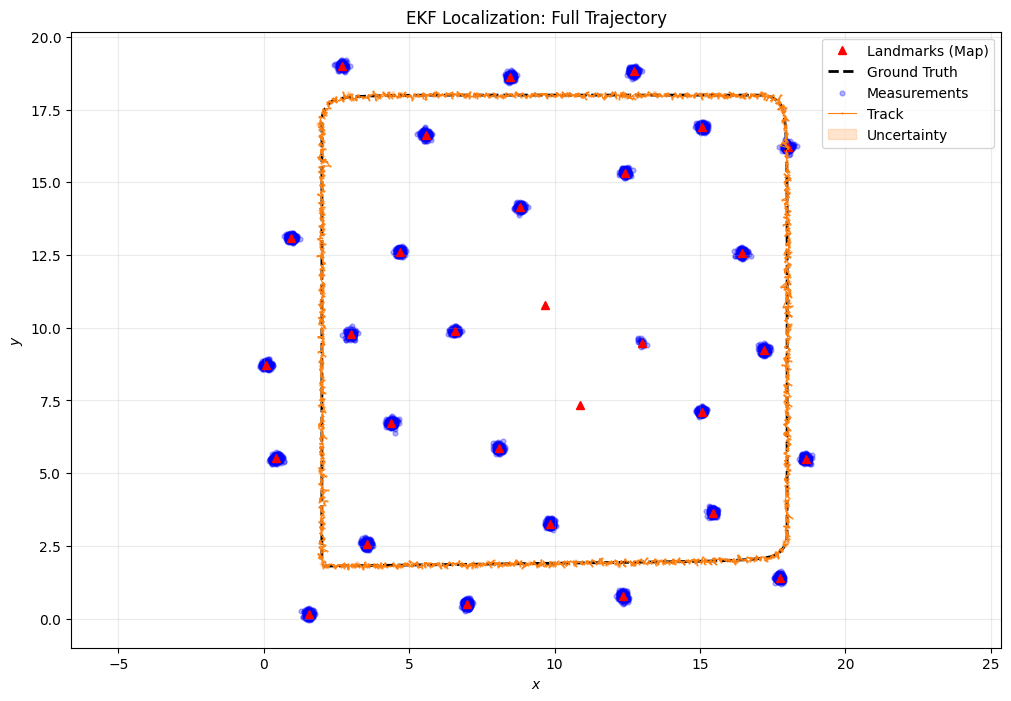

In [38]:
# Experiment 1: full trajectory view
draw_ekf_result(
    M=M,
    gt_traj=gt_traj,
    estim_coords=estim_coords,
    estim_cov=estim_cov,
    meas_coords=meas_coords,
    title='EKF Localization: Full Trajectory',
    traj_step=1,
    meas_step=1,
    start_idx=0,
    end_idx=None,
    ellipse_stride=50,
    ellipse_scale=1.0,
    track_lw=0.8,
    track_ms=0.5,
    meas_alpha=0.30,
    ellipse_alpha=0.20
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


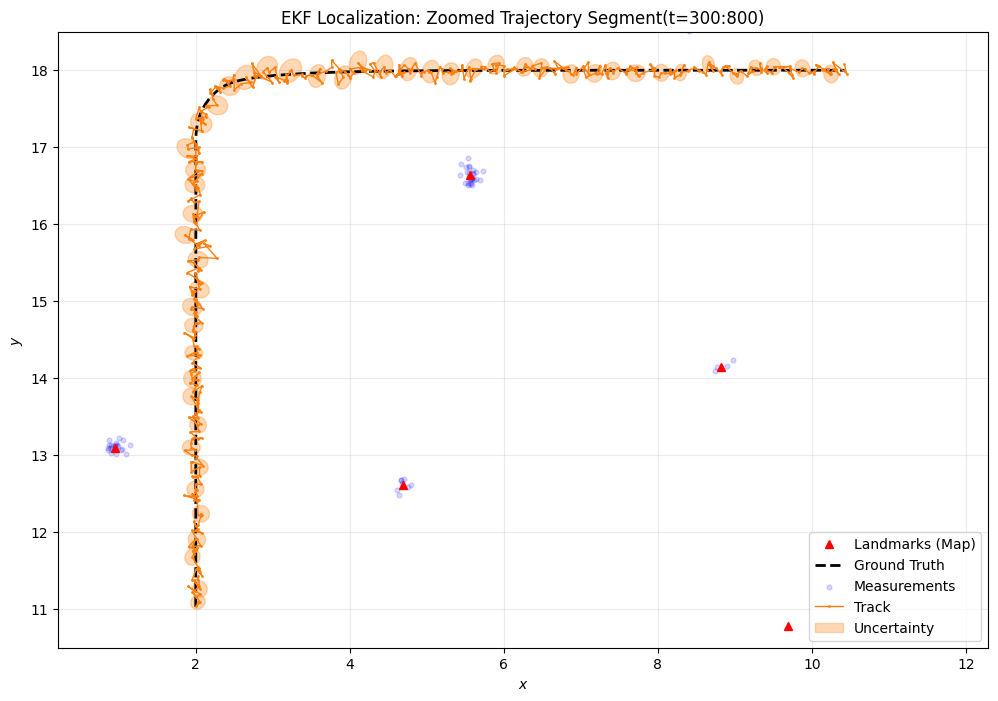

In [39]:
# Experiment 2: cropped trajectory view (better uncertainty visibility + zoom)
start_idx = 300
end_idx = 800

draw_ekf_result(
    M=M,
    gt_traj=gt_traj,
    estim_coords=estim_coords,
    estim_cov=estim_cov,
    meas_coords=meas_coords,
    title=f'EKF Localization: Zoomed Trajectory Segment(t={start_idx}:{end_idx})',
    traj_step=1,
    meas_step=25,
    start_idx=start_idx,
    end_idx=end_idx,
    ellipse_stride=10,
    ellipse_scale=1.8,
    track_lw=1.0,
    track_ms=1.0,
    meas_alpha=0.15,
    ellipse_alpha=0.30,
    xlim=(1.5, 11.0),
    ylim=(10.5, 18.5)
)

## **Extra plots**

Additional plots to understand EKF behavior


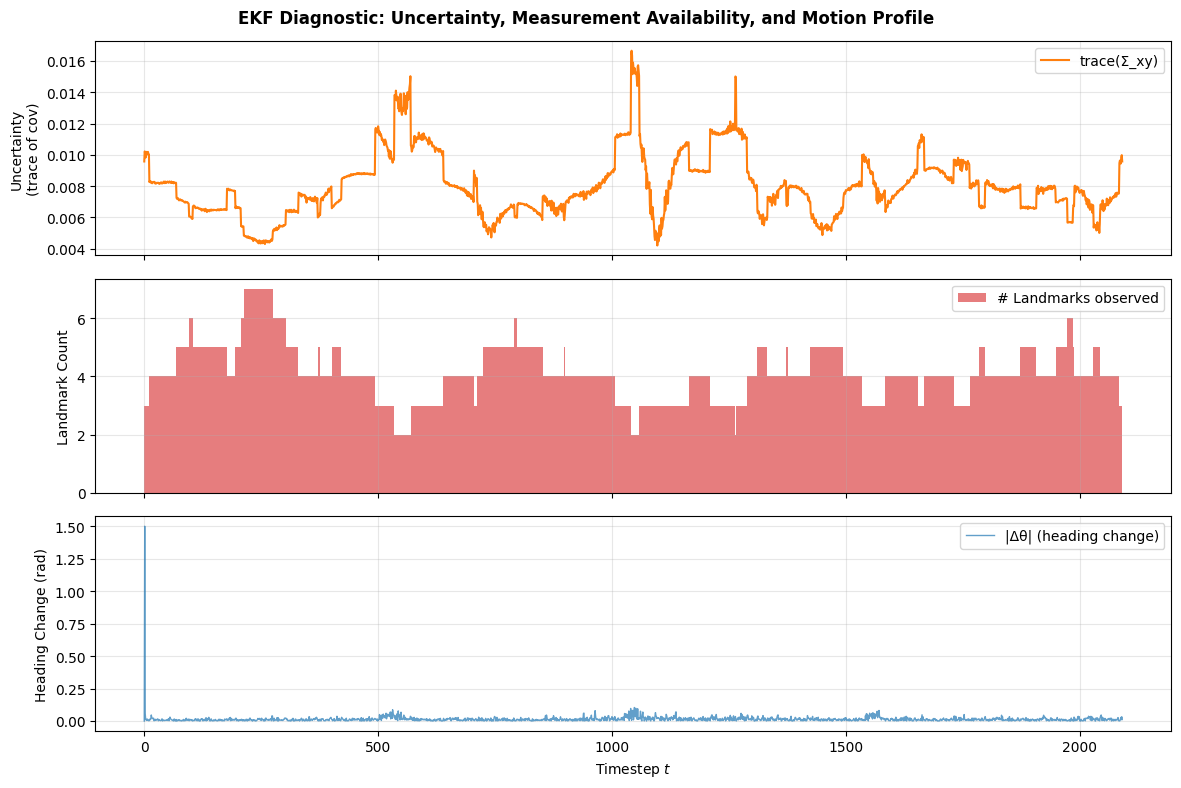

In [34]:
# Diagnostic 1: Uncertainty Evolution Over Time
from scipy.stats import norm

# Compute trace of Σ_xy, heading changes, and landmark count per step
trace_cov = []
landmark_counts = []
heading_changes = []

for i, cov_mat in enumerate(estim_cov):
    trace_cov.append(np.trace(cov_mat[0:2, 0:2]))
    landmark_counts.append(data['z'][i].shape[1] if i < len(data['z']) else 0)
    if i > 0:
        dtheta = estim_coords[i, 2] - estim_coords[i-1, 2]
        heading_changes.append(abs(wrapToPi(dtheta)))
    else:
        heading_changes.append(0)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(trace_cov, linewidth=1.5, color='tab:orange', label='trace(Σ_xy)')
axes[0].set_ylabel('Uncertainty\n(trace of cov)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(range(len(landmark_counts)), landmark_counts, width=1, color='tab:red', alpha=0.6, label='# Landmarks observed')
axes[1].set_ylabel('Landmark Count')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(heading_changes, linewidth=1, color='tab:blue', alpha=0.7, label='|Δθ| (heading change)')
axes[2].set_ylabel('Heading Change (rad)')
axes[2].set_xlabel('Timestep $t$')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle('EKF Diagnostic: Uncertainty, Measurement Availability, and Motion Profile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


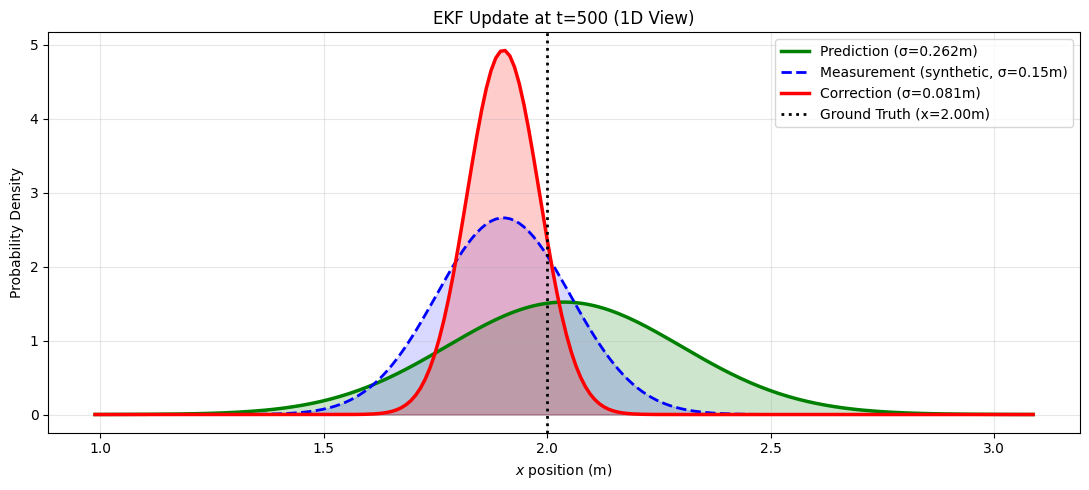

In [40]:
# Diagnostic 2: 1D Gaussian Bell Curves (Prediction vs Measurement vs Correction)
# Highlight a moment during corner (high uncertainty)
t_focus = 500

# Extract x-component at this timestep
mu_pred = estim_coords[t_focus-1]  # Previous estimate (used for prediction)
S_pred = estim_cov[t_focus-1]
sigma_x_pred = np.sqrt(S_pred[0, 0])

# After prediction (before correction) — simulate by running predict only
mu_bar, S_bar = ekf_predict(
    mu_pred.reshape(3, 1), 
    S_pred, 
    [data['odom'][t_focus-1], data['odom'][t_focus]], 
    R
)
mu_bar = np.asarray(mu_bar).flatten()
sigma_x_bar = np.sqrt(S_bar[0, 0])

# After correction (actual estimate)
mu_corrected = estim_coords[t_focus]
sigma_x_corrected = np.sqrt(estim_cov[t_focus][0, 0])

# Ground truth
x_gt = gt_traj[t_focus][0]

# Plot 1D Gaussians
x_range = np.linspace(mu_bar[0] - 4*sigma_x_bar, mu_bar[0] + 4*sigma_x_bar, 200)

fig, ax = plt.subplots(figsize=(11, 5))

# Prediction (before measurement)
pred_pdf = norm.pdf(x_range, mu_bar[0], sigma_x_bar)
ax.plot(x_range, pred_pdf, 'g-', linewidth=2.5, label=f'Prediction (σ={sigma_x_bar:.3f}m)')
ax.fill_between(x_range, pred_pdf, alpha=0.2, color='green')

# Measurement likelihood (synthetic: narrow, centered near measurement)
meas_pdf = norm.pdf(x_range, mu_corrected[0], 0.15)
ax.plot(x_range, meas_pdf, 'b--', linewidth=2, label='Measurement (synthetic, σ=0.15m)')
ax.fill_between(x_range, meas_pdf, alpha=0.15, color='blue')

# Corrected (posterior)
corr_pdf = norm.pdf(x_range, mu_corrected[0], sigma_x_corrected)
ax.plot(x_range, corr_pdf, 'r-', linewidth=2.5, label=f'Correction (σ={sigma_x_corrected:.3f}m)')
ax.fill_between(x_range, corr_pdf, alpha=0.2, color='red')

# Ground truth
ax.axvline(x_gt, color='black', linestyle=':', linewidth=2, label=f'Ground Truth (x={x_gt:.2f}m)')

ax.set_xlabel('$x$ position (m)')
ax.set_ylabel('Probability Density')
ax.set_title(f'EKF Update at t={t_focus} (1D View)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


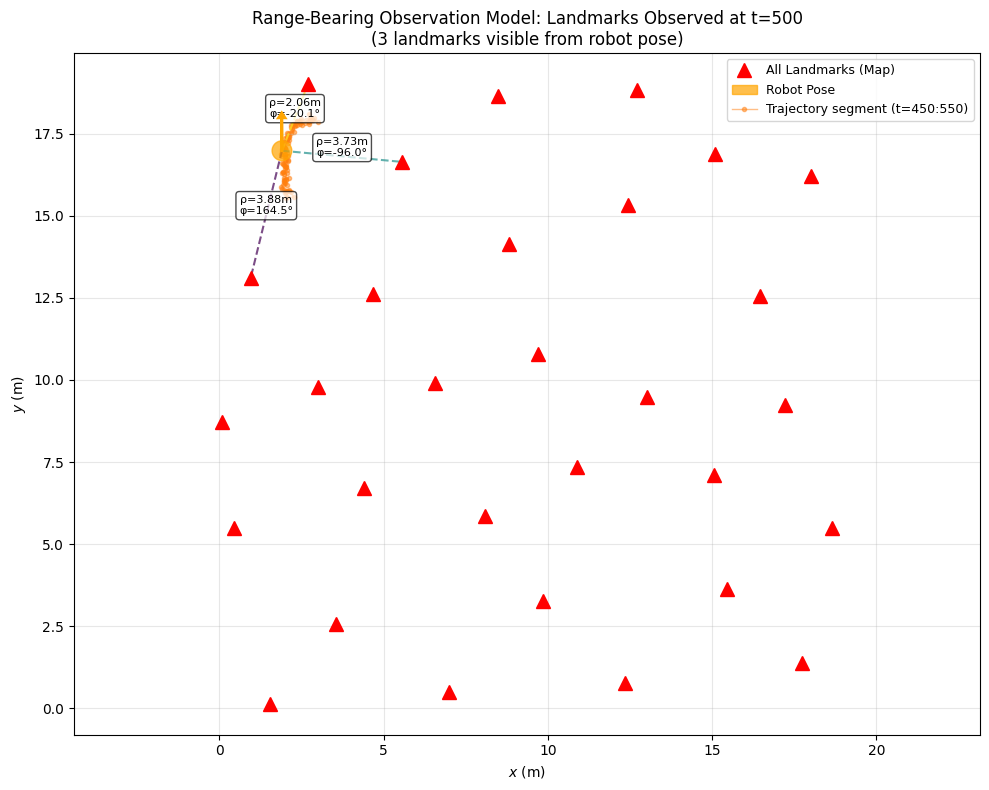

At t=500: Robot observes 3 landmarks
Robot pose: x=1.90m, y=16.98m, θ=90.3°


In [36]:
# Diagnostic 3: Range-Bearing Lines of Sight (Observation Model Visualization)
# Show which landmarks the robot observes and from which pose

t_viz = 500  # Same timestep for consistency

mu_pose = estim_coords[t_viz]
z_t = data['z'][t_viz]

fig, ax = plt.subplots(figsize=(10, 8))

# Plot landmarks
ax.plot(M[:, 0], M[:, 1], '^r', markersize=10, label='All Landmarks (Map)', zorder=3)

# Plot robot pose
robot_circle = plt.Circle((mu_pose[0], mu_pose[1]), 0.3, color='orange', alpha=0.7, label='Robot Pose', zorder=4)
ax.add_patch(robot_circle)

# Plot heading direction
heading_len = 1.0
ax.arrow(mu_pose[0], mu_pose[1], 
         heading_len * np.cos(mu_pose[2]), 
         heading_len * np.sin(mu_pose[2]), 
         head_width=0.2, head_length=0.15, fc='orange', ec='orange', linewidth=2, zorder=4)

# Plot range-bearing lines for observed landmarks
colors_cycle = plt.cm.viridis(np.linspace(0, 1, max(1, z_t.shape[1])))

for k in range(z_t.shape[1]):
    rho_k = z_t[0, k]
    phi_k = z_t[1, k]
    lm_id = int(z_t[2, k])
    
    # Landmark position in map
    lm_pos = M[lm_id]
    
    # Draw line from robot to landmark
    ax.plot([mu_pose[0], lm_pos[0]], [mu_pose[1], lm_pos[1]], 
            color=colors_cycle[k], linewidth=1.5, alpha=0.7, linestyle='--', zorder=2)
    
    # Annotate with range and bearing
    mid_x = (mu_pose[0] + lm_pos[0]) / 2
    mid_y = (mu_pose[1] + lm_pos[1]) / 2
    ax.text(mid_x, mid_y, f'ρ={rho_k:.2f}m\nφ={np.degrees(phi_k):.1f}°', 
            fontsize=8, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Plot estimated trajectory segment around this timestep
start_t = max(0, t_viz - 50)
end_t = min(len(estim_coords), t_viz + 50)
ax.plot(estim_coords[start_t:end_t, 0], estim_coords[start_t:end_t, 1], 
        'o-', color='tab:orange', markersize=3, linewidth=1, alpha=0.5, label=f'Trajectory segment (t={start_t}:{end_t})', zorder=1)

ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title(f'Range-Bearing Observation Model: Landmarks Observed at t={t_viz}\n({z_t.shape[1]} landmarks visible from robot pose)')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

print(f'At t={t_viz}: Robot observes {z_t.shape[1]} landmarks')
print(f'Robot pose: x={mu_pose[0]:.2f}m, y={mu_pose[1]:.2f}m, θ={np.degrees(mu_pose[2]):.1f}°')
